In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('./brake_csv/day_3_regen_23m_trial_v43.csv')

In [4]:
df.columns

Index(['time', 'lat', 'lon', 'alt', 'yaw', 'pitch', 'roll', 'vx', 'vy', 'vz',
       'ax', 'ay', 'az', 'yaw_rate', 'pitch_rate', 'roll_rate',
       'uncorrect_yaw'],
      dtype='object')

<Axes: ylabel='Density'>

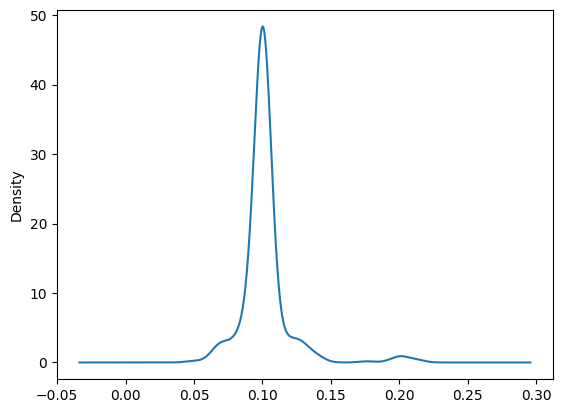

In [5]:
# df.time.diff().mean()
df["time"] = pd.to_datetime(df["time"])
df["time"].diff().dt.total_seconds().plot(kind='kde')

<Axes: >

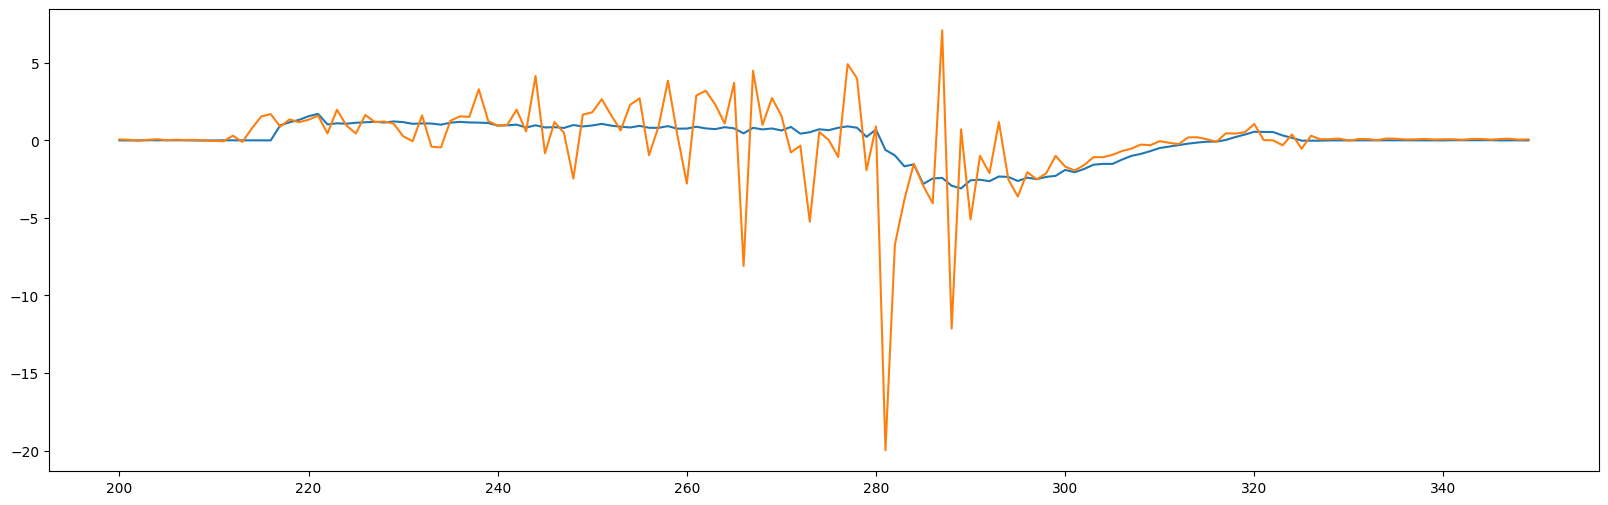

In [26]:
dv = df.vx.diff(periods=5).iloc[200:350]
dt = df.time.diff(periods=5).iloc[200:350].dt.total_seconds()
a = dv/dt
a.plot(kind='line',figsize=(20,6))
df.ax.iloc[200:350].plot(kind='line',figsize=(20,6))

21.9798 25.04794538321878


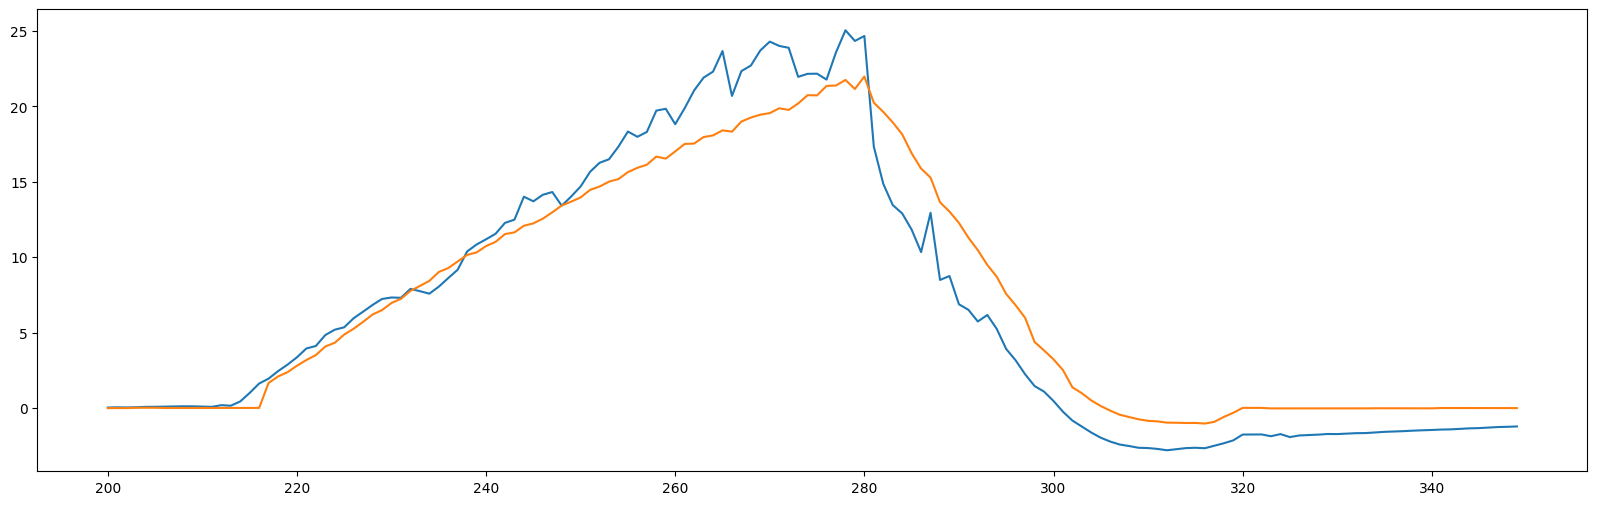

In [25]:
DT = df.time.iloc[200:350].diff().dt.total_seconds().mean()
vx = df.ax.iloc[200:350].cumsum()*DT*18/5
vx.plot(figsize=(20,6))
V = df.vx.iloc[200:350]*18/5
V.plot(figsize=(20,6))
print(V.max() , vx.max())

<Axes: >

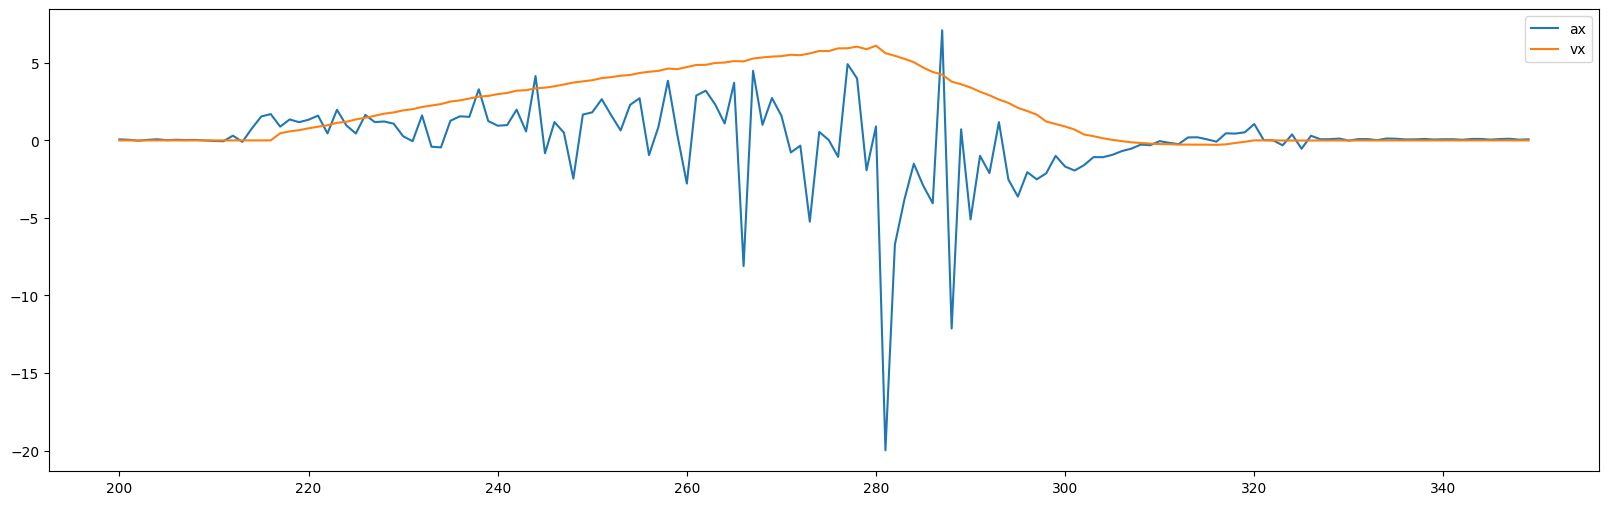

In [ ]:
show = ['ax' , 'vx']

df[show].iloc[200:350].plot(kind='line',figsize=(20,6))

<Axes: >

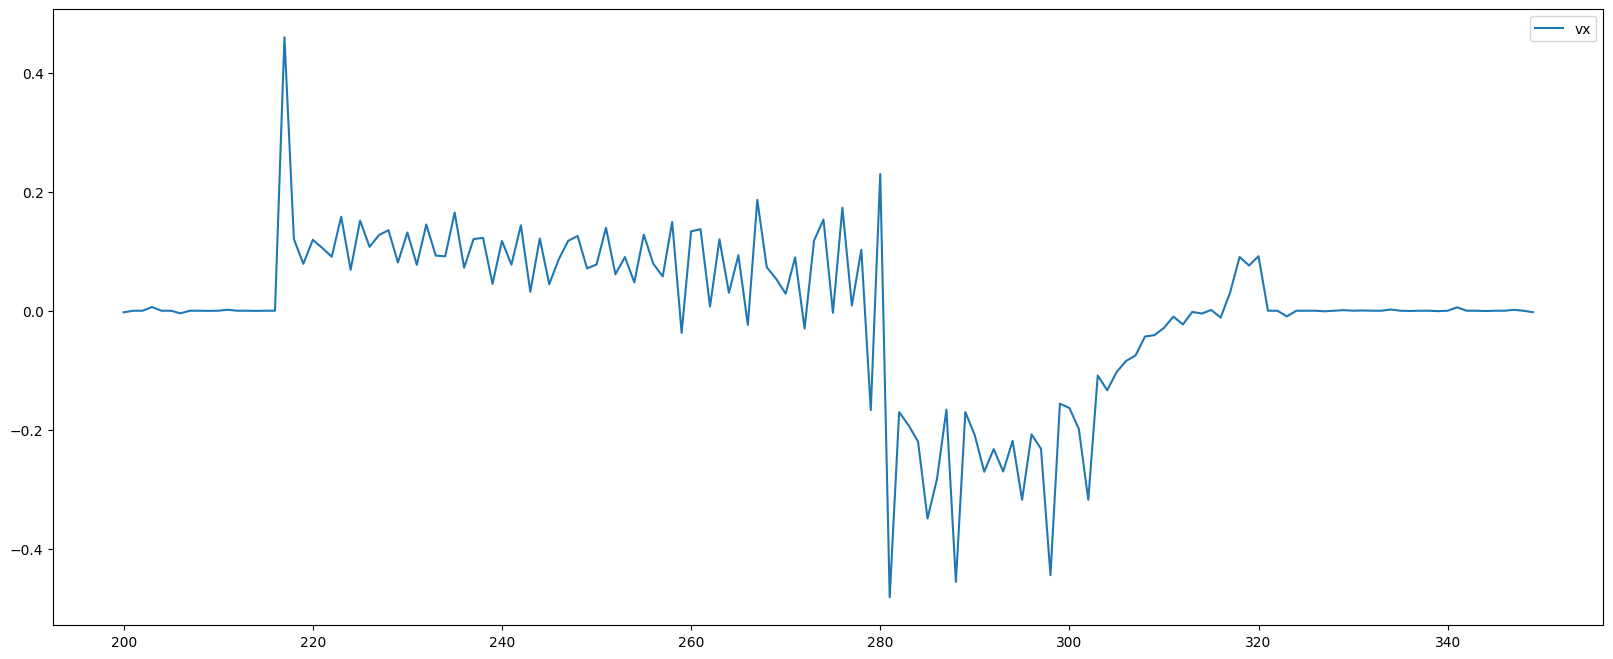

In [ ]:
# impuslse response estimate   step(t) - step(t-1) 

show = ['vx']
df[show].diff().iloc[200:350].plot(kind='line',figsize=(20,8))

In [ ]:
## State space model 
Th = 0.5  # time headway 
t1 = 0.1 
t2 = 0.2

A = [[0 , 1, -Th] , [0 , 0 , -1], [0 , 0 , t1]]
B = [[0] , [0] , [t2]]

C = []